# Reranker를 활용한 RAG 챗봇 고도화

## 실습 목표
---
RAG 과정에서 Reranker를 활용하여 챗봇의 성능을 높일 수 있는 방법을 학습합니다.

## 실습 목차
---

1. **Reranker 구현:** LangGraph 기반 챗봇에 Reranker를 구현하고, Graph 구조를 변경합니다.
   
2. **챗봇 고도화:** Reranker의 파라미터를 조정하며 최적의 구성을 탐색합니다.

## 0. 환경 설정
- 필요한 라이브러리를 불러옵니다.

In [1]:
import io
import os
import time
from typing import List, Dict, Any, Tuple, Optional
import pandas as pd
from IPython.display import Image, display
from langchain.document_loaders import PyPDFLoader
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_chroma import Chroma
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, StateGraph
from typing_extensions import TypedDict

- Ollama를 통해 llama 3.1 8B 모델을 불러옵니다.

In [ ]:
!ollama pull llama3.1
!ollama pull qwen3-embedding:0.6b

llama 3.1 8B 모델을 사용하는 ChatOllama 객체를 생성합니다.

In [39]:
llm = ChatOllama(model="llama3.1", temperature=0)
route_llm = ChatOllama(model="llama3.1", format="json")

data_dir = "data"

pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"

인공지능 산업 동향 연구 문서를 불러옵니다.
- 출처: 소프트웨어정책연구소 (SRPI) 2023년 국내외 인공지능 산업 동향 연구 보고서 (일부 발췌)
  - 본 과정에서는 전체 보고서 중 제2장 인공지능 산업 현황 및 전망 구간만 발췌하여 사용합니다.
  - https://spri.kr/posts/view/23728?code=research&study_type=&board_type=&flg=#none

In [ ]:
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

# 시장 조사 문건을 불러옵니다.
doc_path = os.path.join(data_dir, pdf_data_name)
loader = PyPDFLoader(doc_path)
docs = loader.load()

# Split text 
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=10)
docs = text_splitter.split_documents(docs)

len_docs = [len(doc.page_content) for doc in docs]
print(f"총 Document 개수: {len(docs)}")
print(f"Document 별 길이: {len_docs}")
print(f"Document 별 길이 평균: {sum(len_docs) / len(len_docs)}")

Reranker 객체를 정의합니다.

In [5]:
top_n_reranked_docs = 3
# 모델 초기화
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")

# 상위 3개의 문서를 선택하는 Reranker
reranker = CrossEncoderReranker(model=cross_encoder, top_n=top_n_reranked_docs)

/home/elicer/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`OllamaEmbeddings`를 활용해 벡터로 변환하고, Chroma DB에 저장합니다.
- 변환 과정은 약 1분 정도 소요됩니다.

In [6]:
%%time
# 저장된 VectorStore를 불러올 때는 아래 주석을 해제하여 사용합니다.
# vectorstore = Chroma(
#     embedding_function=embeddings,
#     persist_directory="./vectorstore/chroma"
# )

vectorstore = Chroma.from_documents(
    docs,
    embedding=embeddings,
    persist_directory="./vectorstore/chroma"
)

# Reranker를 통해 한번 더 정렬할 예정이므로, 탐색할 k값을 top_n의 5배로 설정합니다.
db_retriever = vectorstore.as_retriever(
    search_kwargs={"k": top_n_reranked_docs * 5}
)

CPU times: user 637 ms, sys: 90.5 ms, total: 728 ms
Wall time: 32 s


## 1. 각 기능 별 그래프 노드 정의

- PDF 문서 기반 RAG 챗봇을 정의합니다.

In [40]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, LLM이 생성한 텍스트, 데이터, 코드를 저장합니다.
    question: str
    generation: str
    data: str


# 그래프를 구성하기 위해 StateGraph 객체를 생성합니다.
# 생성자의 인자로 State를 전달하여 Node 간에 정보를 전달할 때 State type을 사용함을 명시합니다.
workflow = StateGraph(State)

In [41]:
def answer(state: State) -> State:
    # 데이터를 쿼리하지 않고 답변을 바로 생성합니다.
    print("---답변 생성---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]

    return {"question": question, "generation": llm.invoke(question).content}

def rerank(query: str, _docs: List[Document]) -> List[Document]:
    reranked_docs = reranker.compress_documents(_docs, query)
    return reranked_docs

def retrieval(state: State):
    """
    데이터 검색을 수행합니다.

    Args:
        state (dict): 현재 그래프 상태

    Returns:
        state (dict): 검색된 데이터를 포함한 새로운 State
    """
    print("---데이터 검색---")  # 현재 상태를 확인하기 위한 Print문
    question = state["question"]

    # Retrieval Chain
    # question을 db_retriever에 전달하여 문서를 1차로 검색하고, rerank 함수를 통해 정렬합니다.
    # 이후 상위 top_n개의 문서를 반환합니다.
    retrieval_chain = (
        db_retriever
        | (lambda _retrieved_docs: rerank(question, _retrieved_docs))
    )
    data = retrieval_chain.invoke(question)

    return {"question": question, "data": data}

In [42]:
def answer_with_retrieved_data(state: State):
    """
    검색된 데이터를 바탕으로 답변을 생성합니다.

    Args:
        state (dict): 현재 그래프 상태

    Returns:
        state (dict): LLM의 답변을 포함한 새로운 State
    """

    print(
        "---검색된 데이터를 바탕으로 답변 생성---"
    )  # 현재 상태를 확인하기 위한 Print문

    question = state["question"]
    data = state["data"]

    messages_with_contexts = [
        ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
        ("human", "정보: {context}.\n{question}."),
    ]
    prompt_with_context = ChatPromptTemplate.from_messages(messages_with_contexts)

    # 체인 구성
    qa_chain = prompt_with_context | llm | StrOutputParser()

    generation = qa_chain.invoke({"context": data, "question": question})
    return {"question": question, "data": data, "generation": generation}

**라우팅 전문가 페르소나**를 적용한 체인을 통해 원하는 로직을 선택할 수 있도록 설정해봅시다. 

In [43]:
# 시스템 메시지에 사용 가능한 툴과 각 툴을 사용할 상황을 명시합니다.
# 수월한 선택을 위해 JSON 형식으로 출력하도록 프롬프트에 지정합니다.
route_system_message = """당신은 사용자의 질문에 RAG 사용 여부를 결정하는 전문가입니다.
인공지능 산업, 시장 동향, 기업 동향, 정책, 투자 등과 관련된 질문이라면 'rag'를 선택하고,
그렇지 않다면(일상 대화, 개인적 취향 등) 'plain_answer'를 선택하세요.

예시:
질문: "2022년 AI 투자 규모는?" -> {{"route": "rag"}}
질문: "챗GPT 관련 최근 동향은?" -> {{"route": "rag"}}
질문: "오늘 저녁 뭐 먹을까?" -> {{"route": "plain_answer"}}
질문: "너는 누구야?" -> {{"route": "plain_answer"}}

답변은 'route' 키 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
route_user_message = "{question}"
route_prompt = ChatPromptTemplate.from_messages(
    [("system", route_system_message), ("human", route_user_message)]
)

# 로직 선택용 ChatOllama 객체를 생성합니다. format="json" 인자를 적용하여 출력 양식을 json으로 강제합니다.
# 같은 질문에 항상 같은 대답을 유도하기 위해 temperature를 0으로 설정합니다.
route_llm = ChatOllama(model="llama3.1", format="json", temperature=0)
router_chain = route_prompt | route_llm | JsonOutputParser()

다양한 질문에 대해 테스트 해보고, 그 결과를 확인해 봅시다.

In [44]:
print(router_chain.invoke({"question": "인공지능 산업 현황 및 전망에 대해 알려줘"}))
print(router_chain.invoke({"question": "오늘 저녁 뭐 먹을까?"}))

{'route': 'rag'}
{'route': 'plain_answer'}


대부분 잘 결정하는 것을 볼 수 있습니다.<br>
이 체인을 활용해서 고도화된 `init_answer` 함수를 정의합니다.

In [45]:
def init_answer(state: State) -> str:
    "초기 질문의 경로를 결정합니다."
    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    return {"question": question, "generation": route}


def route_question(state: State) -> str:
    route = state["generation"]
    return route.lower().strip()

 노드와 간선을 그래프에 추가합니다.

In [52]:
## 그래프 구성

workflow = StateGraph(State)

# 앞서 정의한 Node를 모두 추가합니다.
workflow.add_node("init_answer", init_answer)
workflow.add_node("rag", retrieval)

workflow.add_node("plain_answer", answer)
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)

# 시작지점을 정의합니다.
workflow.set_entry_point("init_answer")

# 간선을 정의합니다.
# END는 종결 지점을 의미합니다.
workflow.add_edge(
    "plain_answer", END
)  # workflow.set_finish_point("answer")와 동일합니다.
workflow.add_edge("answer_with_retrieval", END)
workflow.add_edge("rag", "answer_with_retrieval")


# 조건부 간선을 정의합니다.
# init_answer 노드의 답변을 바탕으로 decide_query 함수에서 query 또는 answer로 분기합니다.
workflow.add_conditional_edges(
    "init_answer",
    route_question,
    # 어떤 노드로 이동할지 mapping합니다. 없어도 무방하지만, Graph의 가독성을 높일 수 있습니다.
    {
        "rag": "rag",
        "plain_answer": "plain_answer",
    },
)

Node, Edge, 분기를 모두 구성했으니 이제 그래프를 컴파일 하고, 그 구조를 확인해 봅시다.

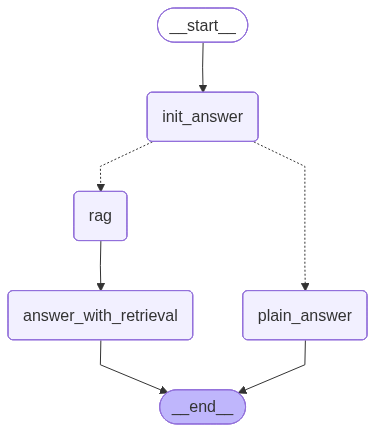

In [53]:
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

이제 챗봇을 사용해봅시다.

- 예시 질문 (인공지능 산업 동향 연구 문서 활용): 인공지능 산업 현황 및 전망에 대해 알려줘
- 예시 질문 (데이터 무관): 오늘 저녁 뭐 먹을까?

답변 생성에는 평균 20~30초 정도 소요됩니다. 1분 넘게 답변이 생성되지 않을 경우 강제 종료 후 재시작 해주세요.

In [ ]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        # graph.invoke 함수를 사용하여 그래프를 실행하고, 최종 결과를 반환합니다.
        # 답변 생성에는 약 1분 정도 소요됩니다.
        response = graph.invoke({"question": question})
        print("Assistant: ", response["generation"])

질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): 구글·마이크로소프트·오픈AI·앤스로픽이 공동 설립한 AI 안전 협의기구의 이름은?
---데이터 검색---
---검색된 데이터를 바탕으로 답변 생성---
--- 검색된 문서 (rerank 이후 top 3) ---
[0] 앤스로픽 4개사, 프런티어 모델 포럼 출범9)10)6) https://www.reuters.com/technology/expedia-group-launches-in-app-feature-powered-by-chatgpt-2023-04-04/7) 슬랙은 2013년 설립된 세계 최대의 기업용 사무 메신저 업체로, 2020년 세계 1위 고객관계관리(CRM) 소프트웨어 업체인 세일즈포스(Salesforce)에 인수됨8) https://www.pcworld.com/article/1534320/several-bots-will-be-typing-on-chatgpt-for-slack.html9) Google, A new partnership to promote responsible AI, 2023.07.26.;

[1] 2023년 5월 OpenAI가 협력하여 Slack용 챗GPT 봇을 출시하였다8). 기업은 슬랙용 챗GPT 앱을 활용하여 업무에 적합하고, 신뢰할 수 있는 고객 데이터와 필수적인 업무 지식에 보다 쉽게 접근해 효율적인 업무와 신속한 의사결정을 할 수 있다. 슬랙에서 오가는 여러 대화는 챗GPT가 자동으로 요약해주고, 관련 자료도 빠르게 찾는 것이 가능gke. Slack용 챗GPT 앱은 OpenAI의 최첨단 대규모 언어 모델의 기능을 Slack의 대화형 인터페이스에 심층적으로 통합하였다. OpenAI는 슬랙 플랫폼의 다양한 소프트웨어 개발 도구, 프레임워크 및 개발 도구를 활용하여 슬랙용 챗GPT 앱을 구축하여 앱이 처음부터 안전하고 확장 가능하도록 지원한다. 이외에도 FiscalNote, Instacart, Kayak 등 다수의 기업들이 챗GPT를 기반으로 재무, 식품, 여행 등 

In [51]:
def answer_with_retrieved_data(state: State):
    print("---검색된 데이터를 바탕으로 답변 생성---")
    question = state["question"]
    data = state["data"]

    print("--- 검색된 문서 (rerank 이후 top 3) ---")
    for i, doc in enumerate(data):
        print(f"[{i}] {doc.page_content}\n")

    # Document 객체가 아니라 순수 텍스트만 추출해서 context로 사용
    context_text = "\n\n".join(doc.page_content for doc in data)

    messages_with_contexts = [
        ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
        ("human", "정보: {context}.\n{question}."),
    ]
    prompt_with_context = ChatPromptTemplate.from_messages(messages_with_contexts)

    qa_chain = prompt_with_context | llm | StrOutputParser()
    generation = qa_chain.invoke({"context": context_text, "question": question})
    return {"question": question, "data": data, "generation": generation}